In [1]:
import wandb
import numpy as np
import pandas as pd
from scipy import stats
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
import seaborn as sns


api = wandb.Api()

In [2]:
def fetch_runs(group, entity="redstag", project="thesis"):
    """Fetch finished runs from a wandb group.

    Returns:
        data: dict[aug][seq] -> list of f1 scores
        seq_df: DataFrame with columns aug, seq, f1 (mean across seeds)
    """
    runs = api.runs(f"{entity}/{project}", filters={"group": group})
    data = defaultdict(lambda: defaultdict(list))

    for run in runs:
        if run.state != "finished":
            continue
        f1 = run.summary.get("test/f1")
        if f1 is None:
            continue
        try:
            seq = int(run.name.split("seq_")[1].split("_")[0])
            aug = int(run.name.split("aug_")[1])
        except (IndexError, ValueError):
            continue
        data[aug][seq].append(f1)

    aug_levels = sorted(data.keys())
    print(f"Group: {group}")
    for aug in aug_levels:
        n_runs = sum(len(v) for v in data[aug].values())
        print(f"  aug={aug}: {len(data[aug])} sequences, {n_runs} runs")

    seq_df = pd.DataFrame([
        {"aug": aug, "seq": seq, "f1": np.mean(data[aug][seq])}
        for aug in aug_levels
        for seq in sorted(data[aug].keys())
    ])
    return data, seq_df


def check_completion(data, expected_seeds=3):
    """Print diagnostic report of incomplete or missing runs."""
    all_seqs = set(seq for seqs in data.values() for seq in seqs)

    print(f"Incomplete combos (fewer than {expected_seeds} finished runs):")
    found = False
    for aug in sorted(data.keys()):
        for seq in sorted(data[aug].keys()):
            n = len(data[aug][seq])
            if n < expected_seeds:
                print(f"  aug={aug:4d}, seq={seq}: {n}/{expected_seeds} runs")
                found = True
    if not found:
        print("  (none)")

    print("\nSequences missing entirely from an aug level:")
    found = False
    for aug in sorted(data.keys()):
        missing = all_seqs - set(data[aug].keys())
        if missing:
            print(f"  aug={aug}: seqs {sorted(missing)} have 0 finished runs")
            found = True
    if not found:
        print("  (none)")


def build_results_df(data):
    """Compute per-aug-level paired t-tests vs aug=0.

    Returns a DataFrame with columns:
        aug, n_seq, mean_f1, std_f1, mean_diff, std_diff, t, p, seq_means
    """
    aug_levels = sorted(data.keys())
    results = []
    for aug in aug_levels:
        common_seqs = sorted(set(data[aug].keys()) & set(data[0].keys()))
        a0 = np.array([np.mean(data[0][s])   for s in common_seqs])
        a1 = np.array([np.mean(data[aug][s]) for s in common_seqs])
        diff = a1 - a0
        if len(common_seqs) >= 2:
            t, p = stats.ttest_rel(a1, a0)
        else:
            t, p = float("nan"), float("nan")
        results.append({
            "aug": aug,
            "n_seq": len(common_seqs),
            "mean_f1": a1.mean(),
            "std_f1": a1.std(),
            "mean_diff": diff.mean(),
            "std_diff": diff.std(),
            "t": t,
            "p": p,
            "seq_means": a1,
        })
    return pd.DataFrame(results)


def plot_f1_by_aug(df, title="Test F1 by augmentation size"):
    """Box + strip plot of per-sequence F1 with p-value panel below.

    Args:
        df: DataFrame with columns aug, mean_f1, p, seq_means (from build_results_df)
        title: plot title
    """
    records = [{"aug": str(row["aug"]), "f1": v} for _, row in df.iterrows() for v in row["seq_means"]]
    plot_df = pd.DataFrame(records)
    aug_order = [str(a) for a in df["aug"]]
    x = np.arange(len(df))

    fig, (ax_box, ax_p) = plt.subplots(2, 1, figsize=(9, 7),
                                        gridspec_kw={"height_ratios": [3, 1]},
                                        sharex=True)

    sns.boxplot(data=plot_df, x="aug", y="f1", order=aug_order, ax=ax_box,
                color="steelblue", fill=True, width=0.5, fliersize=0, linewidth=1.2)
    sns.stripplot(data=plot_df, x="aug", y="f1", order=aug_order, ax=ax_box,
                  color="steelblue", size=5, alpha=0.8, jitter=True)

    ax_box.plot(x, df["mean_f1"], "D", color="firebrick", markersize=6, zorder=4, label="Mean")
    ax_box.axhline(df.loc[df["aug"] == 0, "mean_f1"].values[0],
                   color="grey", linestyle="--", linewidth=1, label="aug=0 mean")
    ax_box.set(ylabel="Test F1", xlabel="", title=title)
    ax_box.yaxis.set_major_locator(ticker.MultipleLocator(0.01))
    ax_box.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax_box.legend(fontsize=9)
    ax_box.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.7)

    colors = ["firebrick" if p < 0.05 else "steelblue" for p in df["p"]]
    ax_p.bar(x, -np.log10(df["p"].clip(lower=1e-6)), color=colors, alpha=0.7)
    ax_p.axhline(-np.log10(0.05), color="firebrick", linestyle="--", linewidth=1, label="p=0.05")
    ax_p.set(ylabel="-log\u2081\u2080(p)", xlabel="Augmentation size (synthetic samples)")
    ax_p.set_xticks(x)
    ax_p.set_xticklabels(aug_order)
    ax_p.legend(fontsize=9)
    ax_p.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.7)

    for i, (_, row) in enumerate(df.iterrows()):
        if not np.isnan(row["p"]):
            ax_p.text(x[i], -np.log10(float(np.clip(row["p"], 1e-6, 1))) + 0.05,
                      f"p={row['p']:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

In [3]:
data, seq_df = fetch_runs("unrestricted_wrup_extended_roberta")
aug_levels = sorted(data.keys())

Group: unrestricted_wrup_extended_roberta
  aug=0: 10 sequences, 30 runs
  aug=128: 10 sequences, 30 runs
  aug=256: 10 sequences, 30 runs
  aug=512: 10 sequences, 30 runs
  aug=1024: 10 sequences, 30 runs
  aug=2048: 10 sequences, 30 runs
  aug=4096: 10 sequences, 30 runs


In [4]:
check_completion(data)

Incomplete combos (fewer than 3 finished runs):
  (none)

Sequences missing entirely from an aug level:
  (none)


In [5]:
df = build_results_df(data)

In [6]:
print(df[["aug", "n_seq", "mean_f1", "std_f1", "mean_diff", "t", "p"]].to_string(index=False))
seq_df["log_aug"] = np.log1p(seq_df["aug"])

 aug  n_seq  mean_f1   std_f1  mean_diff        t        p
   0     10 0.722309 0.029773   0.000000      NaN      NaN
 128     10 0.740307 0.023378   0.017998 3.796576 0.004240
 256     10 0.741872 0.029395   0.019563 3.754050 0.004526
 512     10 0.740328 0.033697   0.018019 1.779812 0.108809
1024     10 0.748065 0.032689   0.025756 3.417894 0.007653
2048     10 0.746343 0.039006   0.024034 2.410426 0.039222
4096     10 0.757468 0.030726   0.035159 3.252925 0.009951


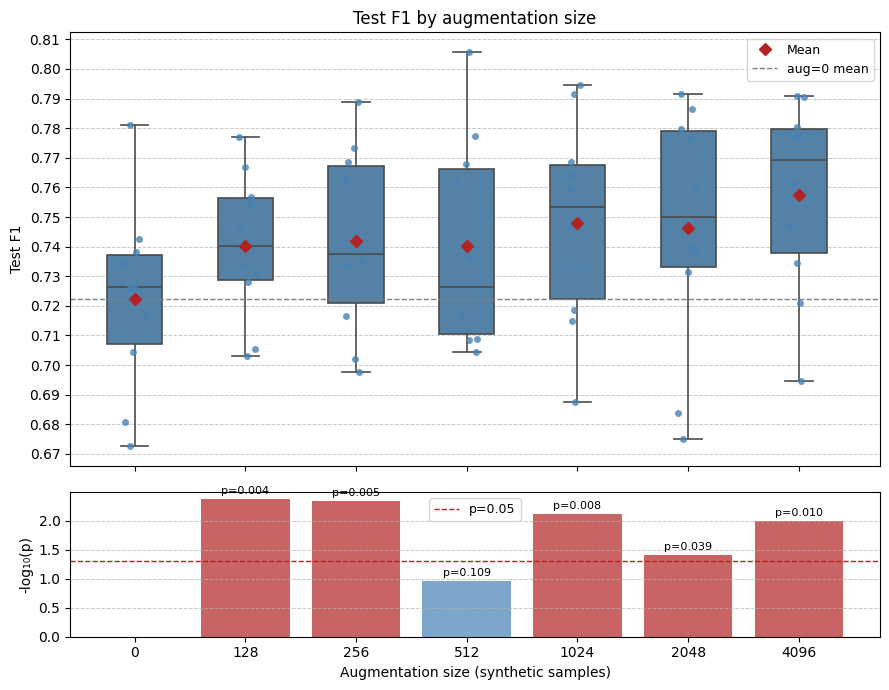

In [7]:
plot_f1_by_aug(df, title="Test F1 by augmentation size")

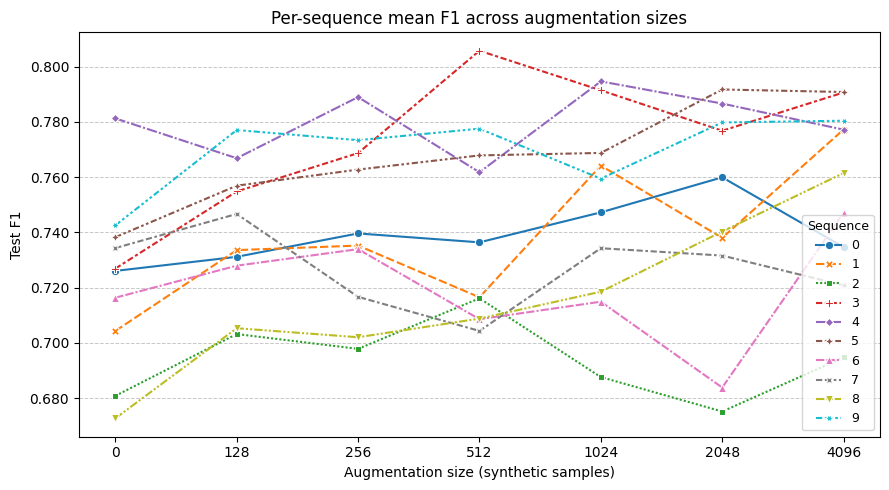

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

aug_to_pos = {aug: i for i, aug in enumerate(aug_levels)}
seq_df["pos"] = seq_df["aug"].map(aug_to_pos)

sns.lineplot(data=seq_df, x="pos", y="f1", hue="seq", style="seq",
             markers=True, dashes=True, ax=ax, palette="tab10")

ax.set_xticks(range(len(aug_levels)))
ax.set_xticklabels(aug_levels)
ax.set(xlabel="Augmentation size (synthetic samples)", ylabel="Test F1",
       title="Per-sequence mean F1 across augmentation sizes")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax.legend(title="Sequence", fontsize=9, title_fontsize=9)
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
import pingouin as pg

# Repeated measures ANOVA: aug as within-subject factor, seq as subject
rm = pg.rm_anova(data=seq_df, dv="f1", within="aug", subject="seq", detailed=True)
print(rm.to_string())

# Post-hoc pairwise comparisons vs aug=0, Holm correction
posthoc = pg.pairwise_tests(data=seq_df, dv="f1", within="aug", subject="seq",
                             parametric=True, padjust="holm")
vs_zero = posthoc[posthoc["A"] == 0][["B", "T", "dof", "p_unc", "p_corr", "hedges"]].copy()
vs_zero.columns = ["aug", "T", "dof", "p-unc", "p-corr (Holm)", "hedges g"]
print("\nPost-hoc vs aug=0:")
print(vs_zero.to_string(index=False))

  Source        SS  DF        MS         F     p_unc       ng2       eps
0    aug  0.009172   6  0.001529  2.043701  0.075486  0.083291  0.606077
1  Error  0.040391  54  0.000748       NaN       NaN       NaN       NaN

Post-hoc vs aug=0:
 aug         T  dof    p-unc  p-corr (Holm)  hedges g
 128  0.191534  9.0 0.852359            1.0  0.069841
 256 -0.784475  9.0 0.452914            1.0 -0.300943
 512 -0.124117  9.0 0.903950            1.0 -0.043748
1024 -0.263737  9.0 0.797922            1.0 -0.056699
2048 -1.713007  9.0 0.120863            1.0 -0.536145
4096 -1.789246  9.0 0.107199            1.0 -0.649303


Group: unrestricted_wrup_2048_dev_test_eval
  aug=0: 20 sequences, 59 runs
  aug=2048: 20 sequences, 60 runs
Incomplete combos (fewer than 3 finished runs):
  aug=   0, seq=14: 2/3 runs

Sequences missing entirely from an aug level:
  (none)
 aug  n_seq  mean_f1   std_f1  mean_diff        t        p
   0     20 0.671794 0.028178   0.000000      NaN      NaN
2048     20 0.681256 0.034035   0.009462 1.078327 0.294388


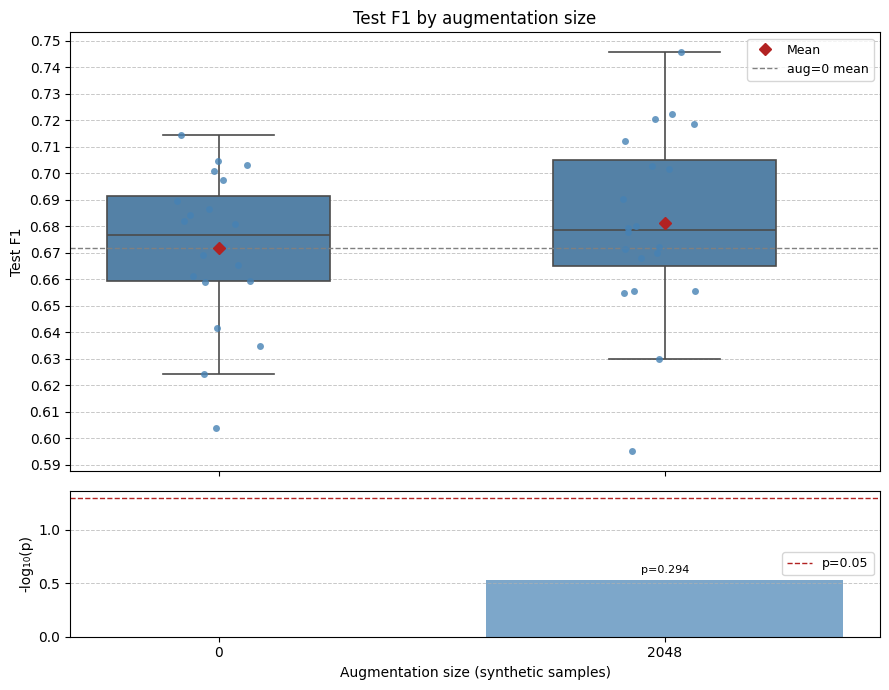

In [10]:
# Confirmatory test: aug=2048 vs aug=0 (pre-registered, new independent runs)
conf_data, conf_seq_df = fetch_runs("unrestricted_wrup_2048_dev_test_eval")
check_completion(conf_data)

conf_df = build_results_df(conf_data)
print(conf_df[["aug", "n_seq", "mean_f1", "std_f1", "mean_diff", "t", "p"]].to_string(index=False))

plot_f1_by_aug(conf_df, title="Test F1 by augmentation size")